In [16]:
import tensorflow as tf

In [17]:
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train/255.0, X_test/255.0
X_train.shape

(60000, 28, 28)

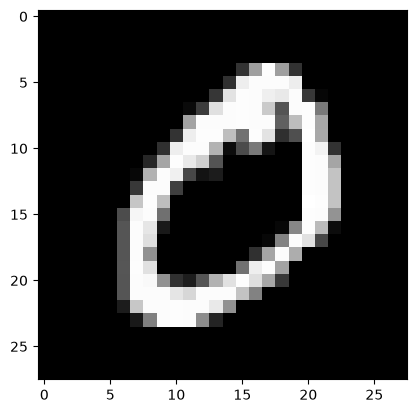

In [43]:
import matplotlib.pyplot as plt 
plt.imshow(X_train[1], cmap='gray')


In [18]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10,activation="softmax")
])

e:\AI and ML\Deep-Learning\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
r = model.fit(X_train, y_train,validation_data=(X_test, y_test),epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9174 - loss: 0.2888 - val_accuracy: 0.9600 - val_loss: 0.1337
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9576 - loss: 0.1410 - val_accuracy: 0.9687 - val_loss: 0.1017
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9671 - loss: 0.1073 - val_accuracy: 0.9722 - val_loss: 0.0872
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9729 - loss: 0.0870 - val_accuracy: 0.9734 - val_loss: 0.0870
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9761 - loss: 0.0749 - val_accuracy: 0.9776 - val_loss: 0.0749
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9794 - loss: 0.0651 - val_accuracy: 0.9769 - val_loss: 0.0794
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9814 - loss: 0.0585 - val_accuracy: 0.9788 - val_loss: 0.0700
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9833 - loss: 0.0525 - 

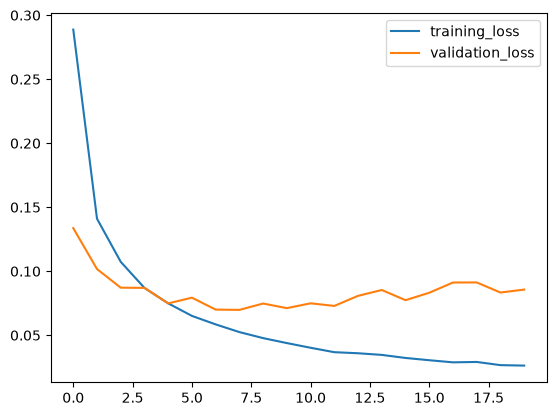

In [21]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='training_loss')
plt.plot(r.history["val_loss"], label='validation_loss')
plt.legend()

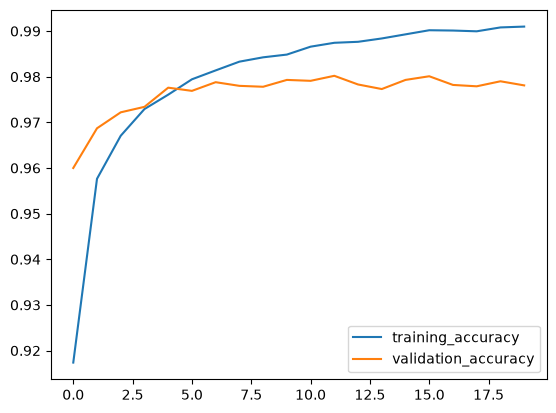

In [22]:
plt.plot(r.history['accuracy'], label='training_accuracy')
plt.plot(r.history['val_accuracy'], label='validation_accuracy')
plt.legend()

In [23]:
print(model.evaluate(X_test, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9781 - loss: 0.0857
[0.08567186444997787, 0.9781000018119812]


In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np 

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(y_test)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[7 2 1 ... 4 5 6]
[7 2 1 ... 4 5 6]


In [29]:
classNames = [str(x) for x in range(0,10)]
print(classNames)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


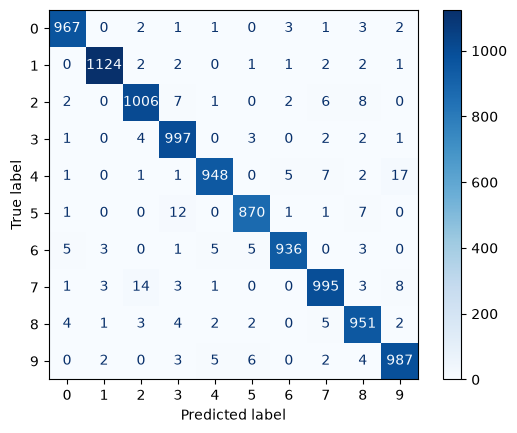

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classNames)
disp.plot(cmap=plt.cm.Blues, values_format="d")

Text(0.5, 1.0, 'True Label: 8, Predicted Label: 1')

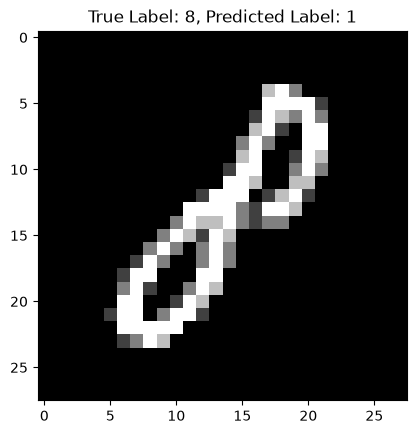

In [ ]:
misclassified_idx = np.where(y_pred != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(X_test[i], cmap='gray')
plt.title(f"True Label: {y_test[i]}, Predicted Label: {y_pred[i]}")